In [1]:
import os

os.chdir("/home/jovyan/work")  # Move to climate-research-workbench root
print(f"CWD: {os.getcwd()}")

CWD: /home/jovyan/work


In [2]:
!pip install -q kornia

In [3]:
# ==========================================
# 🗂  Unique Run Folder Setup
# Every run creates: runs/YYYYMMDD_HHMMSS_leadNd/
#   config.json                    — all hyper-parameters
#   runtime.log                    — epoch logs + timing
#   chart_*_config.json            — per-chart render config
#   srunet_training_curves.png     — loss/RMSE charts
#   srunet_eval_<date>.png         — spatial eval chart
#   metrics.csv                    — final test metrics
# ==========================================
import os
import json as _json
import datetime as _dt

_run_start = _dt.datetime.now()
_run_id    = _run_start.strftime('%Y%m%d_%H%M%S')

# Temporary placeholder; RUN_DIR is refreshed once lead_days is known (Config cell)
RUN_DIR   = os.path.join('runs', f'{_run_id}_lead1d')
os.makedirs(RUN_DIR, exist_ok=True)
print(f'Run folder (placeholder): {RUN_DIR}')

# ── Runtime log helper ──────────────────────────────────────────────────
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')

VAR_LABELS = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]

def _log(msg: str):
    ts   = _dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    line = f'[{ts}] {msg}'
    print(line)
    with open(_LOG_PATH, 'a') as _f:
        _f.write(line + '\n')

_log(f'=== Run started  (id={_run_id}) ===')
_log(f'Run dir: {RUN_DIR}')

# ── Chart-save helper ───────────────────────────────────────────────────
def save_fig(fig, name: str, dpi: int = 150):
    path = os.path.join(RUN_DIR, name)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    _log(f'Chart saved → {path}')
    return path


Run folder (placeholder): runs/20260408_081053_lead1d
[2026-04-08 08:10:53] === Run started  (id=20260408_081053) ===
[2026-04-08 08:10:53] Run dir: runs/20260408_081053_lead1d


## Import Library

In [4]:
import datetime
import xesmf as xe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn.functional as F
import kornia

In [5]:
## Config
scale = 6
lead_days = 1
seed = 42
BATCH_SIZE = 128

# Date-based split boundaries (inclusive)
train_start_date = "2018-01-01"
train_end_date   = "2021-12-31"
val_start_date   = "2022-01-01"
val_end_date     = "2022-06-30"
test_start_date  = "2022-07-01"
test_end_date    = "2022-12-31"

# ── Refresh RUN_DIR now that lead_days is defined ──────────────────────
RUN_DIR = os.path.join('runs', f'{_run_id}_lead{lead_days}d')
os.makedirs(RUN_DIR, exist_ok=True)
_LOG_PATH = os.path.join(RUN_DIR, 'runtime.log')
print(f'Run folder: {RUN_DIR}')

VAR_LABELS_VIZ = ["U10 (m/s)", "V10 (m/s)", "T2m (K)", "TP 24hr (mm)"]
target_date = np.datetime64("2022-08-01")

# ── Persist config ──────────────────────────────────────────────────────
_config = {
    'scenario'         : 'scenario1-unet',
    'run_id'           : _run_id,
    'run_dir'          : RUN_DIR,
    'scale'            : scale,
    'lead_days'        : lead_days,
    'seed'             : seed,
    'BATCH_SIZE'       : BATCH_SIZE,
    'train_start_date' : train_start_date,
    'train_end_date'   : train_end_date,
    'val_start_date'   : val_start_date,
    'val_end_date'     : val_end_date,
    'test_start_date'  : test_start_date,
    'test_end_date'    : test_end_date,
    'started_at'       : _run_start.isoformat(),
}
_cfg_path = os.path.join(RUN_DIR, 'config.json')
with open(_cfg_path, 'w') as _f:
    _json.dump(_config, _f, indent=2)
_log(f'Config saved → {_cfg_path}')

Run folder: runs/20260408_081053_lead1d
[2026-04-08 08:10:55] Config saved → runs/20260408_081053_lead1d/config.json


In [6]:
# Reproducibility
import random

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

## Load Datasets

In [7]:
ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")
ds_truth = xr.open_dataset("data/era5_indonesia_2018-2022.zarr")

/tmp/ipykernel_12635/2386494913.py:1: FutureWarning: In a future version, xarray will not decode the variable 'prediction_timedelta' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_forecast = xr.open_dataset("data/ifs_lowres_indonesia_2018-2022.zarr")


## Lead Selection

In [8]:
lead_td = np.timedelta64(lead_days, "D")
ds_forecast = ds_forecast.sel(prediction_timedelta=lead_td)

## Cropping data to this dimension
- Low-res shape  : 24 32
- High-res shape : 144 192

In [9]:
ds_truth    = ds_truth.sortby("latitude")     # ensure south → north
ds_forecast = ds_forecast.sortby("latitude")

tr_lons = ds_truth.longitude.values    # 90.0 → 140.0, 201 pts
tr_lats = ds_truth.latitude.values     # -15.0 → 30.0,  181 pts
fc_lats = ds_forecast.latitude.values  # -16.5 → 31.5
fc_lons = ds_forecast.longitude.values # 88.5  → 150.0

# ── Find forecast coords inside truth domain ──
valid_lons = fc_lons[(fc_lons >= tr_lons.min()) & (fc_lons <= tr_lons.max())]
valid_lats = fc_lats[(fc_lats >= tr_lats.min()) & (fc_lats <= tr_lats.max())]

lon_start = valid_lons[0]   # 90.0
lat_start = valid_lats[0]   # -15.0  ← south start, not 30.0

# ── Snap to truth grid indices ──
lon_start_idx = np.argmin(np.abs(tr_lons - lon_start))  # 0
lat_start_idx = np.argmin(np.abs(tr_lats - lat_start))  # 0

print(f"lon_start={lon_start}, idx={lon_start_idx}, truth={tr_lons[lon_start_idx]}")
print(f"lat_start={lat_start}, idx={lat_start_idx}, truth={tr_lats[lat_start_idx]}")

# ── Available truth points from start ──
avail_lon = len(tr_lons) - lon_start_idx   # 201
avail_lat = len(tr_lats) - lat_start_idx   # 181

# ── Max forecast pts truth can support ──
max_fc_lon = avail_lon // scale   # 201 // 6 = 33
max_fc_lat = avail_lat // scale   # 181 // 6 = 30

# ── Clamp to U-Net friendly size (24×32) ──
max_fc_lon = min(max_fc_lon, 32)
max_fc_lat = min(max_fc_lat, 24)

# ── Crop forecast by index ──
fc_lon_start_idx = np.argmin(np.abs(fc_lons - lon_start))
fc_lat_start_idx = np.argmin(np.abs(fc_lats - lat_start))

ds_fc = ds_forecast.isel(
    longitude=slice(fc_lon_start_idx, fc_lon_start_idx + max_fc_lon),
    latitude =slice(fc_lat_start_idx, fc_lat_start_idx + max_fc_lat),
)
LOW_LON = len(ds_fc.longitude)
LOW_LAT = len(ds_fc.latitude)

# ── Slice truth by exact count ──
ds_tr = ds_truth.isel(
    longitude=slice(lon_start_idx, lon_start_idx + LOW_LON * scale),
    latitude =slice(lat_start_idx, lat_start_idx + LOW_LAT * scale),
)
HIGH_LON = len(ds_tr.longitude)
HIGH_LAT = len(ds_tr.latitude)

print(f"\nForecast domain : lon {ds_fc.longitude.values[0]:.2f}→{ds_fc.longitude.values[-1]:.2f}"
      f"  lat {ds_fc.latitude.values[0]:.2f}→{ds_fc.latitude.values[-1]:.2f}")
print(f"Truth domain    : lon {ds_tr.longitude.values[0]:.2f}→{ds_tr.longitude.values[-1]:.2f}"
      f"  lat {ds_tr.latitude.values[0]:.2f}→{ds_tr.latitude.values[-1]:.2f}")
print(f"\nFinal forecast grid : {LOW_LAT} lat × {LOW_LON} lon")
print(f"Final truth grid    : {HIGH_LAT} lat × {HIGH_LON} lon")
print(f"Scale lon           : {HIGH_LON / LOW_LON:.6f}")
print(f"Scale lat           : {HIGH_LAT / LOW_LAT:.6f}")

lon_ok = np.allclose(ds_tr.longitude.values[::scale], ds_fc.longitude.values, atol=1e-3)
lat_ok = np.allclose(ds_tr.latitude.values[::scale],  ds_fc.latitude.values,  atol=1e-3)
print(f"Lons aligned        : {lon_ok}")
print(f"Lats aligned        : {lat_ok}")

if HIGH_LON == LOW_LON * scale and HIGH_LAT == LOW_LAT * scale and lon_ok and lat_ok:
    print(f"\n✅ Perfect {scale}× alignment!")
else:
    print(f"\n⚠ Still broken.")

lon_start=90.0, idx=0, truth=90.0
lat_start=-13.5, idx=6, truth=-13.5

Forecast domain : lon 90.00→136.50  lat -13.50→21.00
Truth domain    : lon 90.00→137.75  lat -13.50→22.25

Final forecast grid : 24 lat × 32 lon
Final truth grid    : 144 lat × 192 lon
Scale lon           : 6.000000
Scale lat           : 6.000000
Lons aligned        : True
Lats aligned        : True

✅ Perfect 6× alignment!


## Check Missing Value

In [10]:
import numpy as np

def check_nan_summary(ds, name):
    print(f"\n==== {name} ====")
    for var in ds.data_vars:
        data = ds[var].values
        total = data.size
        n_nan = np.isnan(data).sum()
        pct = (n_nan / total) * 100
        print(f"{var:30s} | NaNs: {n_nan:10d} | {pct:.5f}%")

check_nan_summary(ds_fc, "Forecast (Low-res)")
check_nan_summary(ds_tr, "Truth (High-res)")


==== Forecast (Low-res) ====


10m_u_component_of_wind        | NaNs:        768 | 0.02738%


2m_temperature                 | NaNs:        768 | 0.02738%


10m_v_component_of_wind        | NaNs:        768 | 0.02738%


total_precipitation_24hr       | NaNs:        768 | 0.02738%

==== Truth (High-res) ====


10m_u_component_of_wind        | NaNs:          0 | 0.00000%


10m_v_component_of_wind        | NaNs:          0 | 0.00000%


2m_temperature                 | NaNs:          0 | 0.00000%


total_precipitation_24hr       | NaNs:          0 | 0.00000%


## Temporal Allignment data

In [11]:
# ==============================
# 2️⃣ Compute valid time
# ==============================
valid_time = ds_fc.time + lead_td

# ==============================
# 3️⃣ Find common times
# ==============================
common_times = np.intersect1d(valid_time.values,
                              ds_tr.time.values)

print("Common timesteps:", len(common_times))

# ==============================
# 4️⃣ Select only common times
# ==============================
ds_fc = ds_fc.assign_coords(valid_time=valid_time)
ds_fc = ds_fc.sel(valid_time=common_times)
ds_fc = ds_fc.assign_coords(time=ds_fc.valid_time)
ds_fc = ds_fc.drop_vars("valid_time")

ds_tr_aligned = ds_tr.sel(time=common_times)

# ==============================
# 5️⃣ Final check
# ==============================
print("Forecast time == Truth time:",
      np.array_equal(ds_fc.time.values,
                     ds_tr_aligned.time.values))

print("Forecast shape:",
      len(ds_fc.time),
      len(ds_fc.latitude),
      len(ds_fc.longitude))

print("Truth shape:",
      len(ds_tr_aligned.time),
      len(ds_tr_aligned.latitude),
      len(ds_tr_aligned.longitude))

Common timesteps: 3650


Forecast time == Truth time: True
Forecast shape: 3650 24 32
Truth shape: 3650 144 192


## Data model preparation

In [12]:
# ==========================================
# 1️⃣ Variable stacking
# ==========================================
VARS = [
    "10m_u_component_of_wind",
    "10m_v_component_of_wind",
    "2m_temperature",
    "total_precipitation_24hr",
]
TP_IDX = VARS.index("total_precipitation_24hr")  # index 3

# Stack forecast (low-res): (time, channel, lat, lon)
X = np.stack(
    [ds_fc[v].values for v in VARS],
    axis=1
).astype(np.float32)

# Stack truth (high-res): (time, channel, lat, lon)
Y = np.stack(
    [ds_tr_aligned[v].values for v in VARS],
    axis=1
).astype(np.float32)

# ── Fill NaNs in forecast (X) before any processing ──────────────
# X has ~0.027 % NaN values (confirmed in missing-value check above).
# Strategy: per-channel spatial mean imputation — fast and unbiased.
for _c in range(X.shape[1]):
    _ch   = X[:, _c, :, :]                          # (N, H, W)
    _mask = np.isnan(_ch)
    if _mask.any():
        _fill = np.nanmean(_ch)                     # scalar fallback
        _ch[_mask] = _fill
        X[:, _c, :, :] = _ch
        print(f"  X channel {_c}: filled {_mask.sum()} NaNs with mean={_fill:.4f}")
assert not np.isnan(X).any(), "X still contains NaNs after imputation!"
print("X NaN fill complete — no NaNs remain.")

print("Before axis check:")
print("X shape:", X.shape)  # (N, 4, 24, 32)
print("Y shape:", Y.shape)  # (N, 4, 144, 192)

# ==========================================
# 2️⃣ Axis fix (if lat/lon reversed in Y)
# ==========================================
expected_h = X.shape[2] * 6  # 144
expected_w = X.shape[3] * 6  # 192

if Y.shape[2] == expected_w and Y.shape[3] == expected_h:
    Y = np.transpose(Y, (0, 1, 3, 2))
    print("Y axes corrected")

print("Corrected shapes:")
print("X:", X.shape)
print("Y:", Y.shape)

# ==========================================
# 2.5 Log-transform precipitation BEFORE normalisation
# ==========================================
# Precipitation is non-negative & heavily right-skewed; log1p handles zeros safely
print(f"\nBefore log1p — X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"Before log1p — Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

X[:, TP_IDX] = np.log1p(np.clip(X[:, TP_IDX], 0, None))
Y[:, TP_IDX] = np.log1p(np.clip(Y[:, TP_IDX], 0, None))

print(f"After  log1p — X TP min/max: {X[:, TP_IDX].min():.4f} / {X[:, TP_IDX].max():.4f}")
print(f"After  log1p — Y TP min/max: {Y[:, TP_IDX].min():.4f} / {Y[:, TP_IDX].max():.4f}")

# ==========================================
# 3️⃣ Train / Val / Test split (date-based)
#    Split BEFORE normalization!
#    Keep temporal order — no shuffle
# ==========================================
times = ds_fc.time.values
train_mask = (times >= np.datetime64(train_start_date)) & (times <= np.datetime64(train_end_date))
val_mask   = (times >= np.datetime64(val_start_date)) & (times <= np.datetime64(val_end_date))
test_mask  = (times >= np.datetime64(test_start_date)) & (times <= np.datetime64(test_end_date))

assert train_mask.any(), "No samples found for train date range"
assert val_mask.any(), "No samples found for val date range"
assert test_mask.any(), "No samples found for test date range"

X_train = X[train_mask]
X_val   = X[val_mask]
X_test  = X[test_mask]

Y_train = Y[train_mask]
Y_val   = Y[val_mask]
Y_test  = Y[test_mask]

print("\nDate-based split sizes:")
print(f"  Train : {len(X_train)} ({str(times[train_mask][0])[:10]} → {str(times[train_mask][-1])[:10]})")
print(f"  Val   : {len(X_val)} ({str(times[val_mask][0])[:10]} → {str(times[val_mask][-1])[:10]})")
print(f"  Test  : {len(X_test)} ({str(times[test_mask][0])[:10]} → {str(times[test_mask][-1])[:10]})")

# ==========================================
# 4️⃣ Normalization — train stats only!
#    SEPARATE stats for X (low-res) and Y (high-res)
#    because they live on different grids
# ==========================================
# X stats: (1, C, 1, 1)
X_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
X_std  = X_train.std( axis=(0, 2, 3), keepdims=True)

# Y stats: (1, C, 1, 1)
Y_mean = Y_train.mean(axis=(0, 2, 3), keepdims=True)
Y_std  = Y_train.std( axis=(0, 2, 3), keepdims=True)

X_train = (X_train - X_mean) / (X_std + 1e-6)
X_val   = (X_val   - X_mean) / (X_std + 1e-6)
X_test  = (X_test  - X_mean) / (X_std + 1e-6)

Y_train = (Y_train - Y_mean) / (Y_std + 1e-6)
Y_val   = (Y_val   - Y_mean) / (Y_std + 1e-6)
Y_test  = (Y_test  - Y_mean) / (Y_std + 1e-6)

# Save stats for denormalization at inference
# NOTE: expm1() needed after denormalising the TP channel
norm_stats = {
    "X_mean": torch.tensor(X_mean, dtype=torch.float32),
    "X_std" : torch.tensor(X_std,  dtype=torch.float32),
    "Y_mean": torch.tensor(Y_mean, dtype=torch.float32),
    "Y_std" : torch.tensor(Y_std,  dtype=torch.float32),
    "variables": VARS,
    "tp_index": TP_IDX,
    "log1p_applied": True,
}
print("\nX norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={X_mean[0,i,0,0]:.4f}, std={X_std[0,i,0,0]:.4f}")
print("Y norm stats per channel:")
for i, v in enumerate(VARS):
    print(f"  {v}: mean={Y_mean[0,i,0,0]:.4f}, std={Y_std[0,i,0,0]:.4f}")

# ==========================================
# 5️⃣ Convert to PyTorch tensors
# ==========================================
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val,   dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)

Y_train = torch.tensor(Y_train, dtype=torch.float32)
Y_val   = torch.tensor(Y_val,   dtype=torch.float32)
Y_test  = torch.tensor(Y_test,  dtype=torch.float32)

print("\nFinal tensor shapes:")
print(f"  X_train : {X_train.shape}")
print(f"  Y_train : {Y_train.shape}")
print(f"  X_val   : {X_val.shape}")
print(f"  Y_val   : {Y_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Y_test  : {Y_test.shape}")

# ==========================================
# 6️⃣ DataLoaders
# ==========================================
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(seed)

train_loader = DataLoader(
    TensorDataset(X_train, Y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=g,
)
val_loader = DataLoader(
    TensorDataset(X_val, Y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    TensorDataset(X_test, Y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"\nDataLoaders ready:")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

# ==========================================
# 7️⃣ Denormalization helper (use at inference)
# ==========================================
def denormalize(tensor, mu, sig, tp_idx=TP_IDX):
    """Reverse z-score, then expm1 on the TP channel."""
    mu  = mu.to(tensor.device)
    sig = sig.to(tensor.device)
    out = tensor * (sig + 1e-6) + mu
    out[:, tp_idx] = torch.expm1(out[:, tp_idx])  # reverse log1p
    return out

  X channel 0: filled 768 NaNs with mean=-1.4693
  X channel 1: filled 768 NaNs with mean=0.4053
  X channel 2: filled 768 NaNs with mean=299.7216
  X channel 3: filled 768 NaNs with mean=0.0066
X NaN fill complete — no NaNs remain.
Before axis check:
X shape: (3650, 4, 32, 24)
Y shape: (3650, 4, 144, 192)
Y axes corrected
Corrected shapes:
X: (3650, 4, 32, 24)
Y: (3650, 4, 192, 144)

Before log1p — X TP min/max: 0.0000 / 0.2689
Before log1p — Y TP min/max: -0.0000 / 0.5992


After  log1p — X TP min/max: 0.0000 / 0.2382
After  log1p — Y TP min/max: 0.0000 / 0.4695



Date-based split sizes:
  Train : 2919 (2018-01-02 → 2021-12-31)
  Val   : 361 (2022-01-01 → 2022-06-30)
  Test  : 367 (2022-07-01 → 2022-12-31)



X norm stats per channel:
  10m_u_component_of_wind: mean=-1.5117, std=4.1487
  10m_v_component_of_wind: mean=0.4299, std=3.1888
  2m_temperature: mean=299.7371, std=2.1349
  total_precipitation_24hr: mean=0.0063, std=0.0084
Y norm stats per channel:
  10m_u_component_of_wind: mean=-1.2598, std=4.0508
  10m_v_component_of_wind: mean=0.2606, std=3.3895
  2m_temperature: mean=299.8726, std=2.2523
  total_precipitation_24hr: mean=0.0061, std=0.0104

Final tensor shapes:
  X_train : torch.Size([2919, 4, 32, 24])
  Y_train : torch.Size([2919, 4, 192, 144])
  X_val   : torch.Size([361, 4, 32, 24])
  Y_val   : torch.Size([361, 4, 192, 144])
  X_test  : torch.Size([367, 4, 32, 24])
  Y_test  : torch.Size([367, 4, 192, 144])

DataLoaders ready:
  Train batches : 23
  Val batches   : 3
  Test batches  : 3


In [13]:
# ==========================================
# Building Blocks
# ==========================================

class DoubleConv(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class Down(nn.Module):
    """MaxPool → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_ch, out_ch),
        )

    def forward(self, x):
        return self.net(x)


class Up(nn.Module):
    """Upsample → concat skip → DoubleConv"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        # Pad if spatial dims mismatch
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        x  = F.pad(x, [dx // 2, dx - dx // 2,
                        dy // 2, dy - dy // 2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)


class UpscaleBlock(nn.Module):
    """
    6× upscale via three 2× bilinear steps + refinement conv.
    Input  : (B, C, 24, 32)   — low-res encoder output
    Output : (B, C, 144, 192) — high-res prediction
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up1   = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch,      in_ch // 2, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch // 2),
            nn.ReLU(inplace=True),
        )
        self.up2   = nn.Sequential(
            nn.Upsample(scale_factor=3, mode="bilinear", align_corners=False),
            nn.Conv2d(in_ch // 2, in_ch // 4, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(in_ch // 4),
            nn.ReLU(inplace=True),
        )
        self.refine = nn.Conv2d(in_ch // 4, out_ch, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.up1(x)    # (B, C//2, 48,  64)
        x = self.up2(x)    # (B, C//4, 144, 192)
        return self.refine(x)


# ==========================================
# U-Net + 6× Super-Resolution Head
# ==========================================

class SRUNet(nn.Module):
    """
    Input  : (B, 4, 24, 32)   — low-res forecast
    Output : (B, 4, 144, 192) — high-res prediction
    """
    def __init__(self, in_ch=4, out_ch=4, base_ch=64):
        super().__init__()

        # ── Encoder ──────────────────────────────
        self.enc1 = DoubleConv(in_ch,       base_ch)      # (B, 64,  24, 32)
        self.enc2 = Down(base_ch,           base_ch * 2)  # (B, 128, 12, 16)
        self.enc3 = Down(base_ch * 2,       base_ch * 4)  # (B, 256,  6,  8)

        # ── Bottleneck ───────────────────────────
        self.bottleneck = Down(base_ch * 4, base_ch * 8)  # (B, 512,  3,  4)

        # ── Decoder ──────────────────────────────
        self.dec3 = Up(base_ch * 8,  base_ch * 4)         # (B, 256,  6,  8)
        self.dec2 = Up(base_ch * 4,  base_ch * 2)         # (B, 128, 12, 16)
        self.dec1 = Up(base_ch * 2,  base_ch)             # (B, 64,  24, 32)

        # ── 6× Super-Resolution Head ─────────────
        self.sr_head = UpscaleBlock(base_ch, out_ch)      # (B, 4, 144, 192)

    def forward(self, x):
        # Encoder
        s1 = self.enc1(x)        # skip 1
        s2 = self.enc2(s1)       # skip 2
        s3 = self.enc3(s2)       # skip 3
        bn = self.bottleneck(s3)

        # Decoder
        x = self.dec3(bn, s3)
        x = self.dec2(x,  s2)
        x = self.dec1(x,  s1)

        # 6× upscale to high-res
        return self.sr_head(x)


# ==========================================
# Quick sanity check
# ==========================================
if __name__ == "__main__":
    model  = SRUNet(in_ch=4, out_ch=4, base_ch=64)
    dummy  = torch.randn(2, 4, 24, 32)   # batch=2, 4 vars, 24×32 low-res
    output = model(dummy)

    print("Input  :", dummy.shape)   # (2, 4,  24,  32)
    print("Output :", output.shape)  # (2, 4, 144, 192)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Params : {total_params:,}")

Input  : torch.Size([2, 4, 24, 32])
Output : torch.Size([2, 4, 144, 192])
Params : 7,724,388


In [14]:
class CombinedLoss(nn.Module):
    """
    Combined loss using DSSIM from Kornia.

    Modes:
    - 'dssim'      : Pure DSSIM
    - 'mae'        : Pure MAE
    - 'dssim+mse'  : alpha * DSSIM + beta * MSE
    - 'dssim+mae'  : alpha * DSSIM + beta * MAE
    """
    def __init__(self, alpha=0.8, beta=0.2, mode='dssim'):
        super().__init__()
        self.alpha = alpha
        self.beta  = beta
        self.mode  = mode
        self.dssim = kornia.losses.SSIMLoss(window_size=11, reduction='mean')

    def _zero(self, ref: torch.Tensor) -> torch.Tensor:
        """Device-safe zero scalar."""
        return torch.tensor(0.0, device=ref.device, dtype=ref.dtype)

    def _gradient_loss(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """L1 loss on spatial gradients (sharpens edges)."""
        def grad(x):
            dy = x[:, :, 1:, :] - x[:, :, :-1, :]
            dx = x[:, :, :, 1:] - x[:, :, :, :-1]
            return dy, dx
        pred_dy,   pred_dx   = grad(pred)
        target_dy, target_dx = grad(target)
        return F.l1_loss(pred_dy, target_dy) + F.l1_loss(pred_dx, target_dx)

    def forward(self, pred: torch.Tensor, target: torch.Tensor):
        """
        Returns:
            total_loss  : scalar used for .backward()
            loss_a      : first component (detached), for logging
            loss_b      : second component (detached), for logging
        """
        if self.mode == 'dssim':
            d = self.dssim(pred, target)
            return d, d.detach(), self._zero(pred)

        elif self.mode == 'mae':
            mae = F.l1_loss(pred, target)          
            return mae, mae.detach(), self._zero(pred)

        elif self.mode == 'dssim+mse':
            d   = self.dssim(pred, target)
            mse = F.mse_loss(pred, target)
            total = self.alpha * d + self.beta * mse
            return total, d.detach(), mse.detach()

        elif self.mode == 'dssim+mae':
            d   = self.dssim(pred, target)
            mae = F.l1_loss(pred, target)
            total = self.alpha * d + self.beta * mae
            return total, d.detach(), mae.detach()

        else:
            raise ValueError(f"Unknown mode: {self.mode}")

In [15]:
def train(
    model,
    train_loader,
    val_loader,
    norm_stats,
    epochs     = 50,
    lr         = 5e-4,
    patience   = 7,
    device     = "cuda" if torch.cuda.is_available() else "cpu",
):
    _log(f"Training started  epochs={epochs} lr={lr} patience={patience}")
    _train_t0 = _dt.datetime.now()
    model = model.to(device)

    Y_mu  = norm_stats["Y_mean"]
    Y_sig = norm_stats["Y_std"]

    criterion = CombinedLoss(mode='mae').to(device)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    history = {
        "train_loss": [], "val_loss": [],
        "train_mse": [], "train_grad": [],
        "val_metrics": [],
    }
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, epochs + 1):

        # ── Train ──────────────────────────────
        model.train()
        train_losses, train_mses, train_grads = [], [], []

        for X_batch, Y_batch in train_loader:
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss, mse, grad = criterion(pred, Y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_mses.append(mse.item())
            train_grads.append(grad.item())

        scheduler.step()

        # ── Validate ───────────────────────────
        model.eval()
        val_losses   = []
        all_preds    = []
        all_targets  = []

        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch = X_batch.to(device)
                Y_batch = Y_batch.to(device)
                pred    = model(X_batch)
                loss, _, _ = criterion(pred, Y_batch)
                val_losses.append(loss.item())
                all_preds.append(pred.cpu())
                all_targets.append(Y_batch.cpu())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)

        # Metrics on full val set
        all_preds   = torch.cat(all_preds,   dim=0)
        all_targets = torch.cat(all_targets, dim=0)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # ── Logging ────────────────────────────
        _emsg = (f"Epoch [{epoch:03d}/{epochs}] "
              f"train={train_loss:.4f} "
              f"val={val_loss:.4f}  lr={scheduler.get_last_lr()[0]:.2e}")
        print(_emsg)
        _log(_emsg)

        # ── Checkpoint + Early Stopping ────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                "epoch"      : epoch,
                "model_state": model.state_dict(),
                "optimizer"  : optimizer.state_dict(),
                "val_loss"   : val_loss,
                "X_mean"     : norm_stats["X_mean"].clone(),
                "X_std"      : norm_stats["X_std"].clone(),
                "Y_mean"     : norm_stats["Y_mean"].clone(),
                "Y_std"      : norm_stats["Y_std"].clone(),
                "variables"  : VARS,
                "tp_index"   : TP_IDX,
                "log1p_applied": True,
            }, os.path.join(RUN_DIR, "best_model.pt"))
            print(f"  💾 Saved best model (val={val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⏹ Early stopping at epoch {epoch} — no improvement for {patience} epochs.")
                # Restore best weights
                best_ckpt = torch.load(os.path.join(RUN_DIR, "best_model.pt"), map_location=device, weights_only=False)
                model.load_state_dict(best_ckpt["model_state"])
                print(f"  Restored best weights from epoch {best_ckpt['epoch']} (val={best_ckpt['val_loss']:.4f})")
                break

    _elapsed = _dt.datetime.now() - _train_t0
    _log(f"Training finished  elapsed={str(_elapsed).split(chr(46))[0]}  best_val_loss={best_val_loss:.6f}")
    return history

In [16]:
model   = SRUNet(in_ch=4, out_ch=4, base_ch=64)
history = train(
    model, train_loader, val_loader, norm_stats,
    epochs=100, lr=5e-4,
)

[2026-04-08 08:11:20] Training started  epochs=100 lr=0.0005 patience=7


Epoch [001/100] train=0.4229 val=0.3949  lr=5.00e-04
[2026-04-08 08:11:23] Epoch [001/100] train=0.4229 val=0.3949  lr=5.00e-04
  💾 Saved best model (val=0.3949)


Epoch [002/100] train=0.2963 val=0.2874  lr=5.00e-04
[2026-04-08 08:11:25] Epoch [002/100] train=0.2963 val=0.2874  lr=5.00e-04
  💾 Saved best model (val=0.2874)


Epoch [003/100] train=0.2717 val=0.2749  lr=4.99e-04
[2026-04-08 08:11:27] Epoch [003/100] train=0.2717 val=0.2749  lr=4.99e-04
  💾 Saved best model (val=0.2749)


Epoch [004/100] train=0.2597 val=0.2702  lr=4.98e-04
[2026-04-08 08:11:30] Epoch [004/100] train=0.2597 val=0.2702  lr=4.98e-04


...

Epoch [018/100] train=0.2148 val=0.2498  lr=4.61e-04
[2026-04-08 08:11:59] Epoch [018/100] train=0.2148 val=0.2498  lr=4.61e-04


Epoch [019/100] train=0.2125 val=0.2486  lr=4.57e-04
[2026-04-08 08:12:02] Epoch [019/100] train=0.2125 val=0.2486  lr=4.57e-04


Epoch [020/100] train=0.2093 val=0.2489  lr=4.52e-04
[2026-04-08 08:12:04] Epoch [020/100] train=0.2093 val=0.2489  lr=4.52e-04


Epoch [021/100] train=0.2072 val=0.2485  lr=4.48e-04
[2026-04-08 08:12:06] Epoch [021/100] train=0.2072 val=0.2485  lr=4.48e-04


Epoch [022/100] train=0.2066 val=0.2503  lr=4.43e-04
[2026-04-08 08:12:08] Epoch [022/100] train=0.2066 val=0.2503  lr=4.43e-04

⏹ Early stopping at epoch 22 — no improvement for 7 epochs.
  Restored best weights from epoch 15 (val=0.2480)
[2026-04-08 08:12:08] Training finished  elapsed=0:00:47  best_val_loss=0.248045


[2026-04-08 08:12:08] Chart config saved → chart_training_curves_config.json
[2026-04-08 08:12:08] Chart saved → runs/20260408_081053_lead1d/srunet_training_curves.png


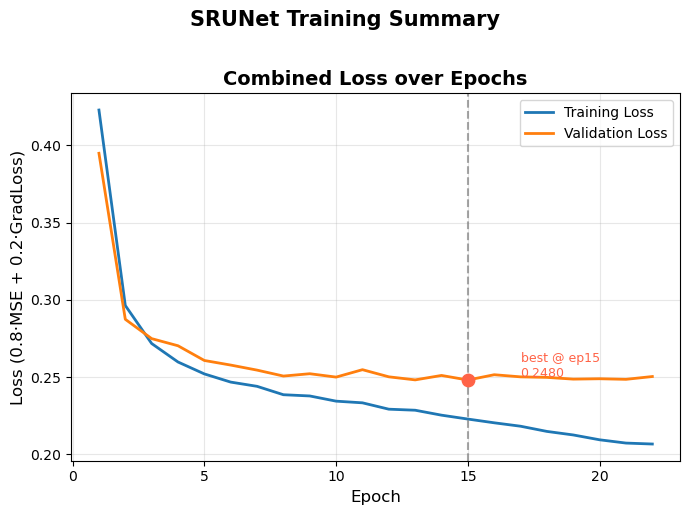


Final Training Loss: 0.206601
Final Validation Loss: 0.250311


In [17]:
# ── Save chart config ───────────────────────────────────────────────────
_chart1_cfg = {
    'chart'         : 'training_curves',
    'figsize'       : [14, 5],
    'loss_alpha'    : 0.8,
    'loss_beta'     : 0.2,
    'best_epoch'    : int(np.argmin(history['val_loss']) + 1),
    'best_val_loss' : float(min(history['val_loss'])),
}
_json.dump(_chart1_cfg, open(os.path.join(RUN_DIR, 'chart_training_curves_config.json'), 'w'), indent=2)
_log('Chart config saved → chart_training_curves_config.json')

import matplotlib.pyplot as plt

fig, (ax1) = plt.subplots(1, 1, figsize=(7, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

# ── Left: Loss (combined = 0.8*MSE + 0.2*GradLoss) ──
ax1.plot(epochs_range, history["train_loss"], label="Training Loss", linewidth=2)
ax1.plot(epochs_range, history["val_loss"],   label="Validation Loss", linewidth=2)

best_epoch = np.argmin(history["val_loss"]) + 1
best_loss  = min(history["val_loss"])
ax1.axvline(best_epoch, color="gray", linestyle="--", alpha=0.7)
ax1.scatter([best_epoch], [best_loss], color="tomato", zorder=5, s=80)
ax1.annotate(
    f"best @ ep{best_epoch}\n{best_loss:.4f}",
    xy=(best_epoch, best_loss),
    xytext=(best_epoch + 2, best_loss + 0.002),
    fontsize=9, color="tomato",
)

ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss (0.8·MSE + 0.2·GradLoss)", fontsize=12)
ax1.set_title("Combined Loss over Epochs", fontsize=14, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

plt.suptitle("SRUNet Training Summary", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "srunet_training_curves.png", dpi=150)
plt.show()

print(f"\nFinal Training Loss: {history['train_loss'][-1]:.6f}")
print(f"Final Validation Loss: {history['val_loss'][-1]:.6f}")

[2026-04-08 08:12:08] Chart config saved → chart_spatial_eval_config.json


[2026-04-08 08:12:11] Chart saved → runs/20260408_081053_lead1d/srunet_eval_2022-08-01.png


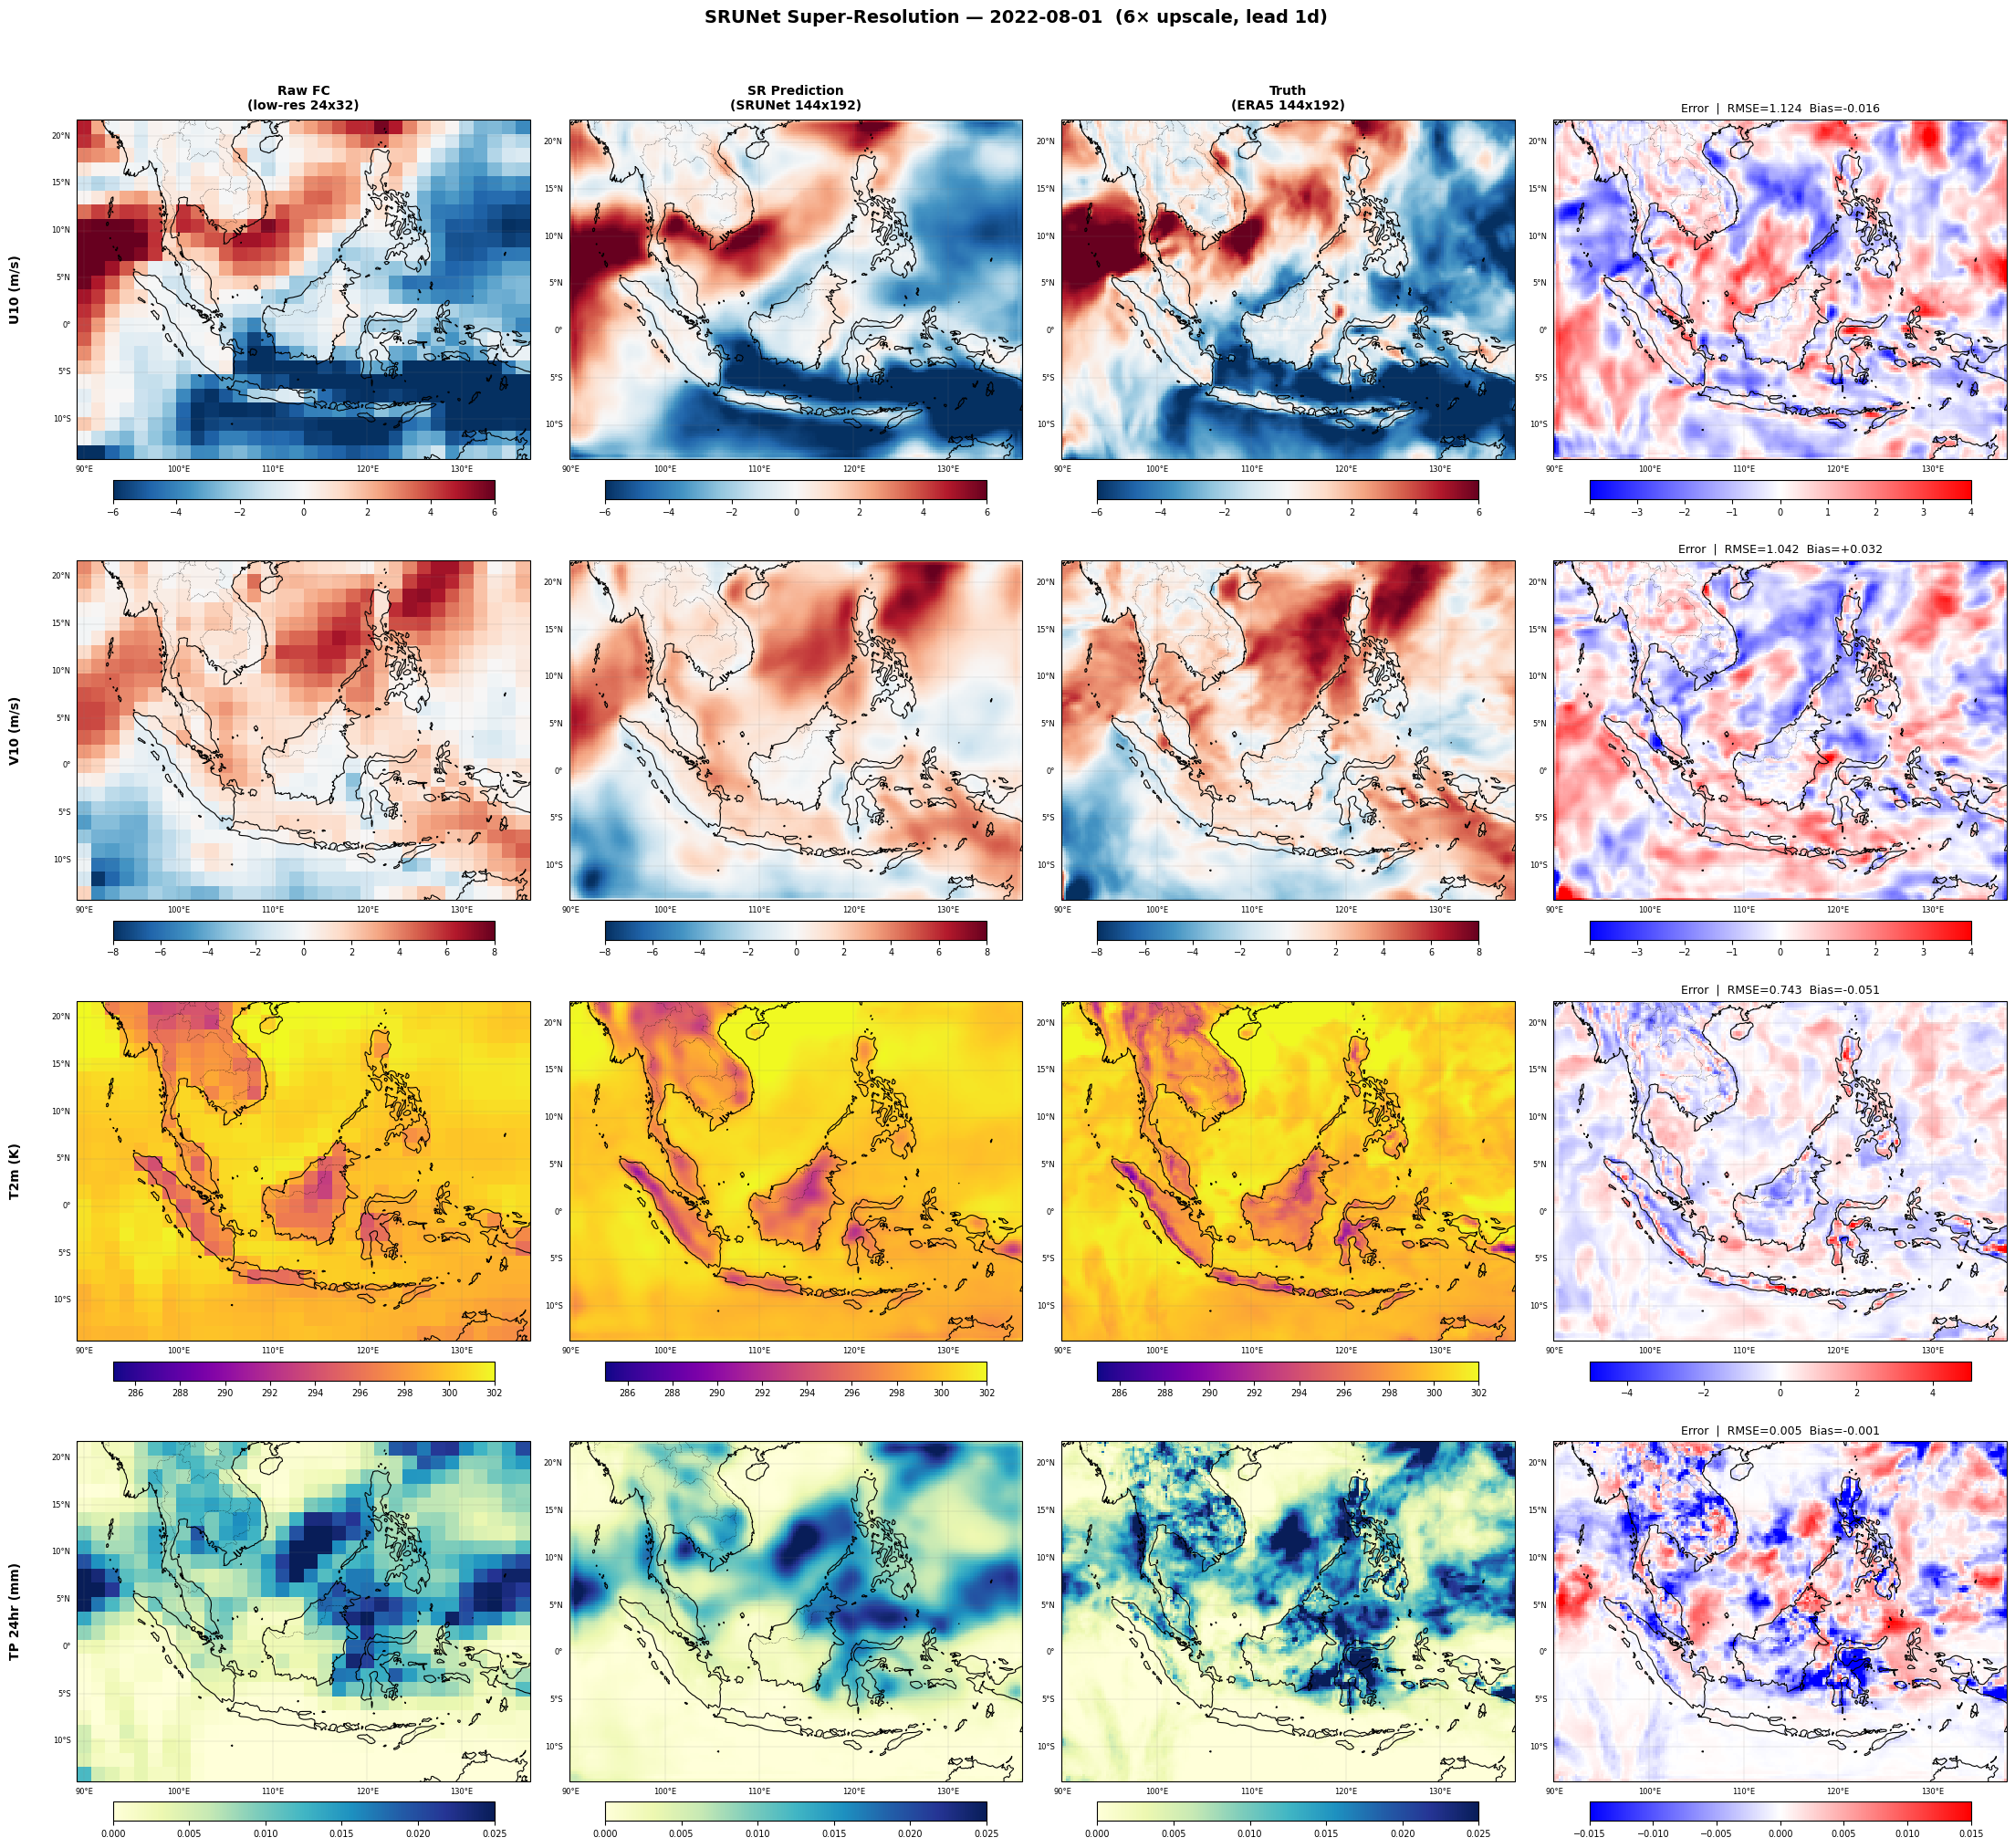

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import torch
import numpy as np


# Hardcoded color ranges (consistent across notebooks for head-to-head)
#                   U10    V10    T2m       TP
FIELD_VMIN = [      -6,    -8,   285,   0.000]
FIELD_VMAX = [       6,     8,   302,   0.025]
ERROR_LIM  = [       4,     4,     5,   0.015]

# Colormaps — same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

# ── Save chart config ───────────────────────────────────────────────────
_chart2_cfg = {
    'chart'          : 'spatial_eval',
    'target_date'    : str(target_date),
    'lead_days'      : lead_days,
    'figsize'        : [22, 20],
    'FIELD_VMIN'     : FIELD_VMIN,
    'FIELD_VMAX'     : FIELD_VMAX,
    'ERROR_LIM'      : ERROR_LIM,
    'VAR_LABELS_VIZ' : VAR_LABELS_VIZ,
    'cmaps_field'    : cmaps_field,
}
_json.dump(_chart2_cfg, open(os.path.join(RUN_DIR, 'chart_spatial_eval_config.json'), 'w'), indent=2)
_log('Chart config saved → chart_spatial_eval_config.json')



# ==============================
# Find index in test split
# ==============================
test_times = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date)).time.values
idx = np.where(test_times == target_date)[0]
if len(idx) == 0:
    raise ValueError(
        f"{target_date} not found in test set.\n"
        f"Available range: {test_times[0]} → {test_times[-1]}"
    )
idx = idx[0]

# ==============================
# Get sample & predict
# ==============================
device = next(model.parameters()).device
model.eval()

X_sample = X_test[[idx]].to(device)
Y_sample = Y_test[[idx]]

with torch.no_grad():
    Y_pred_sample = model(X_sample).cpu()

# Denormalize — keep T2m in Kelvin (no K→°C) to match regrid notebook
Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]
X_mu  = norm_stats["X_mean"]
X_sig = norm_stats["X_std"]

X_dn   = denormalize(X_sample.cpu(), X_mu, X_sig)[0]   # (4, 24,  32)
Y_true = denormalize(Y_sample,       Y_mu, Y_sig)[0]   # (4, 144, 192)
Y_pred = denormalize(Y_pred_sample,  Y_mu, Y_sig)[0]   # (4, 144, 192)

# ==============================
# Coordinate arrays
# ==============================
lons_lr = ds_fc.longitude.values   # (32,)
lats_lr = ds_fc.latitude.values    # (24,)
lons_hr = ds_tr_aligned.longitude.values  # (192,)
lats_hr = ds_tr_aligned.latitude.values   # (144,)

# ==============================
# Plot: 4 rows × 4 cols  (matching regrid_correction.ipynb layout)
# cols: Raw FC | Prediction (SR) | Truth (ERA5) | Error
# ==============================
proj   = ccrs.PlateCarree()
n_vars = len(VAR_LABELS_VIZ)

col_titles = [
    "Raw FC\n(low-res 24x32)",
    "SR Prediction\n(SRUNet 144x192)",
    "Truth\n(ERA5 144x192)",
    "Error\n(Pred - Truth)",
]

# Colormaps — same as regrid notebook
cmaps_field = ["RdBu_r", "RdBu_r", "plasma", "YlGnBu"]

fig, axes = plt.subplots(
    n_vars, 4,
    figsize=(22, 5 * n_vars),
    subplot_kw={"projection": proj},
)

for v in range(n_vars):
    # PyTorch (C, H, W) → numpy (H, W)
    raw_v  = X_dn[v].numpy()       # (24,  32)
    pred_v = Y_pred[v].numpy()     # (144, 192)
    true_v = Y_true[v].numpy()     # (144, 192)
    err_v  = pred_v - true_v

    cmap_f = cmaps_field[v]

    # Hardcoded ranges
    vmin = FIELD_VMIN[v]
    vmax = FIELD_VMAX[v]
    elim = ERROR_LIM[v]

    panels = [
        (lons_lr, lats_lr, raw_v,  cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, pred_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, true_v, cmap_f, vmin,  vmax),
        (lons_hr, lats_hr, err_v,  "bwr",  -elim,  elim),
    ]

    for col, (lons, lats, data, cmap, lo, hi) in enumerate(panels):
        ax = axes[v, col]

        # Ensure data shape is (n_lats, n_lons) for pcolormesh
        if data.shape != (len(lats), len(lons)):
            data = data.T

        im = ax.pcolormesh(
            lons, lats, data,
            cmap=cmap, vmin=lo, vmax=hi,
            shading="nearest",
            transform=proj,
        )
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS,   linewidth=0.4, linestyle=":")
        ax.add_feature(cfeature.LAND,      facecolor="whitesmoke", zorder=0)
        ax.add_feature(cfeature.OCEAN,     facecolor="lightcyan",  zorder=0)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.4)
        gl.top_labels   = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 6}
        gl.ylabel_style = {"size": 6}

        cb = plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, fraction=0.046)
        cb.ax.tick_params(labelsize=7)

        if v == 0:
            ax.set_title(col_titles[col], fontsize=10, fontweight="bold", pad=8)
        if col == 0:
            ax.text(-0.15, 0.5, VAR_LABELS_VIZ[v], transform=ax.transAxes,
                    fontsize=10, fontweight="bold", va="center", rotation=90)

    # RMSE + bias on error panel
    rmse = np.sqrt(np.mean(err_v ** 2))
    bias = np.mean(err_v)
    axes[v, 3].set_title(
        f"Error  |  RMSE={rmse:.3f}  Bias={bias:+.3f}",
        fontsize=9, pad=6,
    )

fig.suptitle(
    f"SRUNet Super-Resolution — {str(target_date)[:10]}  (6× upscale, lead {lead_days}d)",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
save_fig(fig, f"srunet_eval_{str(target_date)[:10]}.png", dpi=150)
plt.show()

In [19]:
# ==========================================
# Helpers: compute_metrics / print_metrics
# ==========================================

def compute_metrics(preds_norm, targets_norm, Y_mu, Y_sig):
    """
    Denormalize both tensors, then compute per-variable
    RMSE, MAE, Bias, and Corr over the full (N, C, H, W) batch.
    Returns: dict  { VAR_LABELS[i]: {RMSE, MAE, Bias, Corr} }
    """
    p_dn = denormalize(preds_norm.clone(),   Y_mu, Y_sig).numpy()  # (N,C,H,W)
    t_dn = denormalize(targets_norm.clone(), Y_mu, Y_sig).numpy()

    results = {}
    for vi, label in enumerate(VAR_LABELS):
        p = p_dn[:, vi]; t = t_dn[:, vi]
        rmse = float(np.sqrt(np.mean((p - t) ** 2)))
        mae  = float(np.mean(np.abs(p - t)))
        bias = float(np.mean(p - t))
        pd_  = p - p.mean(); td_ = t - t.mean()
        with np.errstate(divide="ignore", invalid="ignore"):
            corr = float(
                np.sum(pd_ * td_) /
                (np.sqrt(np.sum(pd_**2) * np.sum(td_**2)) + 1e-12)
            )
        results[label] = {"RMSE": rmse, "MAE": mae, "Bias": bias, "Corr": corr}
    return results


def print_metrics(metrics: dict, prefix: str = "Metrics"):
    """Pretty-print a compute_metrics() result dict and log to runtime.log."""
    hdr  = f"\n{prefix}"
    line = "-" * 72
    print(hdr); print(line)
    _log(hdr)
    for label, m in metrics.items():
        r, a, b, c = m["RMSE"], m["MAE"], m["Bias"], m["Corr"]
        msg = (f"  {label:<22}  RMSE={r:8.4f}  MAE={a:8.4f}  "
               f"Bias={b:+8.4f}  Corr={c:6.4f}")
        print(msg); _log(msg)
    print(line)


# ==========================================
# evaluate_test — loads best checkpoint,
# runs inference on test_loader, returns
# metrics + raw prediction tensors
# ==========================================

def evaluate_test(model, test_loader, norm_stats,
                  device="cuda" if torch.cuda.is_available() else "cpu"):
    ckpt_path = os.path.join(RUN_DIR, "best_model.pt")
    _log(f"Loading checkpoint: {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    model = model.to(device)
    model.eval()

    Y_mu  = norm_stats["Y_mean"]
    Y_sig = norm_stats["Y_std"]

    all_preds   = []
    all_targets = []

    with torch.no_grad():
        for X_batch, Y_batch in test_loader:
            pred = model(X_batch.to(device))
            all_preds.append(pred.cpu())
            all_targets.append(Y_batch)

    all_preds   = torch.cat(all_preds,   dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    metrics = compute_metrics(all_preds, all_targets, Y_mu, Y_sig)
    print_metrics(metrics, prefix="🧪 Test Set Metrics")
    return metrics, all_preds, all_targets


test_metrics, test_preds, test_targets = evaluate_test(
    model, test_loader, norm_stats
)

[2026-04-08 08:12:14] Loading checkpoint: runs/20260408_081053_lead1d/best_model.pt



🧪 Test Set Metrics
------------------------------------------------------------------------
[2026-04-08 08:12:15] 
🧪 Test Set Metrics
  U10 (m/s)               RMSE=  1.1993  MAE=  0.8938  Bias= +0.0066  Corr=0.9533
[2026-04-08 08:12:15]   U10 (m/s)               RMSE=  1.1993  MAE=  0.8938  Bias= +0.0066  Corr=0.9533
  V10 (m/s)               RMSE=  1.1609  MAE=  0.8625  Bias= +0.0799  Corr=0.9371
[2026-04-08 08:12:15]   V10 (m/s)               RMSE=  1.1609  MAE=  0.8625  Bias= +0.0799  Corr=0.9371
  T2m (K)                 RMSE=  0.8138  MAE=  0.5730  Bias= -0.0756  Corr=0.9239
[2026-04-08 08:12:15]   T2m (K)                 RMSE=  0.8138  MAE=  0.5730  Bias= -0.0756  Corr=0.9239
  TP 24hr (mm)            RMSE=  0.0073  MAE=  0.0035  Bias= -0.0009  Corr=0.8027
[2026-04-08 08:12:15]   TP 24hr (mm)            RMSE=  0.0073  MAE=  0.0035  Bias= -0.0009  Corr=0.8027
------------------------------------------------------------------------


In [20]:
# ==============================
# Aggregate test-set evaluation
# (Corrected Spatio-Temporal Metrics)
# ==============================
import numpy as np
import xarray as xr

Y_mu  = norm_stats["Y_mean"]
Y_sig = norm_stats["Y_std"]

# Denormalize model predictions/targets (physical space)
y_pred_phys = denormalize(test_preds.clone(), Y_mu, Y_sig).numpy()
y_true_phys = denormalize(test_targets.clone(), Y_mu, Y_sig).numpy()

# Build baseline exactly like QM notebook:
# low-res ds_fc test slice -> (fill NaN) -> linear interpolation to truth test grid
fc_test_lowres = ds_fc.sel(time=slice(test_start_date, test_end_date)).copy(deep=True)
tr_test_ds = ds_tr_aligned.sel(time=slice(test_start_date, test_end_date))

# Match QM NaN handling before baseline interpolation
for v_name in VARS:
    if np.isnan(fc_test_lowres[v_name].values).any():
        fill_val = float(np.nanmean(fc_test_lowres[v_name].values))
        fc_test_lowres[v_name] = fc_test_lowres[v_name].fillna(fill_val)

fc_test_lowres, tr_test_ds = xr.align(fc_test_lowres, tr_test_ds, join='inner')

# Compute baseline RMSE strictly on xarray path (same definition as QM)
baseline_rmse_by_var = {}
for v_name in VARS:
    low_da, truth_da_xr = xr.align(fc_test_lowres[v_name], tr_test_ds[v_name], join='inner')
    base_da = low_da.interp(
        latitude=truth_da_xr.latitude,
        longitude=truth_da_xr.longitude,
        method='linear',
    )
    base_da, truth_da_xr = xr.align(base_da, truth_da_xr, join='inner')

    base_v_xr = base_da.transpose('time', 'latitude', 'longitude').values
    true_v_xr = truth_da_xr.transpose('time', 'latitude', 'longitude').values
    rmse_base_grid = np.sqrt(np.mean((base_v_xr - true_v_xr) ** 2, axis=0))
    baseline_rmse_by_var[v_name] = float(np.nanmean(rmse_base_grid))

print("\n" + "=" * 100)
print(f"{'Variable':<18} | {'RMSE':>8} | {'MAE':>8} | {'Bias':>8} | {'Corr':>8} | {'Baseline RMSE':>14} | {'Skill':>8}")
print("=" * 100)

for v_idx, v_name in enumerate(VARS):
    pred_v = y_pred_phys[:, v_idx, :, :]
    true_v = y_true_phys[:, v_idx, :, :]

    n = min(pred_v.shape[0], true_v.shape[0])
    pred_v = pred_v[:n]
    true_v = true_v[:n]

    rmse_grid = np.sqrt(np.mean((pred_v - true_v) ** 2, axis=0))
    mae_grid = np.mean(np.abs(pred_v - true_v), axis=0)
    bias_grid = np.mean(pred_v - true_v, axis=0)

    pred_diff = pred_v - np.mean(pred_v, axis=0)
    true_diff = true_v - np.mean(true_v, axis=0)
    cov = np.sum(pred_diff * true_diff, axis=0)
    var_pred = np.sum(pred_diff ** 2, axis=0)
    var_true = np.sum(true_diff ** 2, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        corr_grid = cov / np.sqrt(var_pred * var_true)

    rmse = float(np.nanmean(rmse_grid))
    mae = float(np.nanmean(mae_grid))
    bias = float(np.nanmean(bias_grid))
    corr = float(np.nanmean(corr_grid))

    rmse_base = baseline_rmse_by_var[v_name]
    skill = 1.0 - (rmse / rmse_base) if rmse_base > 0 else 0.0

    label = VAR_LABELS[v_idx]
    print(f"{label:<18} | {rmse:8.4f} | {mae:8.4f} | {bias:+8.4f} | {corr:8.4f} | {rmse_base:14.4f} | {skill:+8.4f}")

print("=" * 100)
print("\nSkill > 0 means SRUNet improves over bilinear interpolation baseline.")

# ── Save final test metrics to CSV ──────────────────────────────────────
import csv as _csv

_metrics_rows = []
for v_idx, v_name in enumerate(VARS):
    _pv = y_pred_phys[:, v_idx, :, :]
    _tv = y_true_phys[:, v_idx, :, :]
    _n = min(_pv.shape[0], _tv.shape[0])
    _pv = _pv[:_n]
    _tv = _tv[:_n]

    _rmse_g = np.sqrt(np.mean((_pv - _tv) ** 2, axis=0))
    _mae_g = np.mean(np.abs(_pv - _tv), axis=0)
    _bias_g = np.mean(_pv - _tv, axis=0)
    _pd = _pv - np.mean(_pv, axis=0)
    _td = _tv - np.mean(_tv, axis=0)
    _cov = np.sum(_pd * _td, axis=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        _corr_g = _cov / np.sqrt(np.sum(_pd**2, axis=0) * np.sum(_td**2, axis=0))

    _rmse = float(np.nanmean(_rmse_g))
    _rbase = baseline_rmse_by_var[v_name]
    _metrics_rows.append({
        'variable': v_name,
        'label': VAR_LABELS[v_idx],
        'RMSE': _rmse,
        'MAE': float(np.nanmean(_mae_g)),
        'Bias': float(np.nanmean(_bias_g)),
        'Corr': float(np.nanmean(_corr_g)),
        'Baseline_RMSE': _rbase,
        'Skill': float(1.0 - (_rmse / _rbase)) if _rbase > 0 else 0.0,
    })

_csv_path = os.path.join(RUN_DIR, 'metrics.csv')
_fields = ['variable', 'label', 'RMSE', 'MAE', 'Bias', 'Corr', 'Baseline_RMSE', 'Skill']
with open(_csv_path, 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fields)
    _w.writeheader()
    _w.writerows(_metrics_rows)
_log(f'Metrics saved → {_csv_path}')

# ── Log run completion ───────────────────────────────────────────────────
_total = _dt.datetime.now() - _run_start
_log(f'=== Run finished  total_elapsed={str(_total).split(".")[0]} ===')
_log(f'All outputs in: {RUN_DIR}')
print(f'\n✅ All outputs saved to: {RUN_DIR}')



Variable           |     RMSE |      MAE |     Bias |     Corr |  Baseline RMSE |    Skill
U10 (m/s)          |   1.1632 |   0.8938 |  +0.0066 |   0.8703 |         1.1679 |  +0.0041
V10 (m/s)          |   1.1249 |   0.8625 |  +0.0799 |   0.8580 |         1.0916 |  -0.0305


T2m (K)            |   0.7084 |   0.5730 |  -0.0756 |   0.8101 |         0.7312 |  +0.0312
TP 24hr (mm)       |   0.0067 |   0.0035 |  -0.0009 |   0.8020 |         0.0060 |  -0.1091

Skill > 0 means SRUNet improves over bilinear interpolation baseline.


[2026-04-08 08:12:15] Metrics saved → runs/20260408_081053_lead1d/metrics.csv
[2026-04-08 08:12:15] === Run finished  total_elapsed=0:01:22 ===
[2026-04-08 08:12:15] All outputs in: runs/20260408_081053_lead1d

✅ All outputs saved to: runs/20260408_081053_lead1d
